Set DATE-AVG to '2022-12-16T08:51:18.051' from MJD-AVG.
Set DATE-END to '2023-01-28T18:36:13.203' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    13.292646 from OBSGEO-[XYZ].
Set OBSGEO-H to 1649518427.990 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


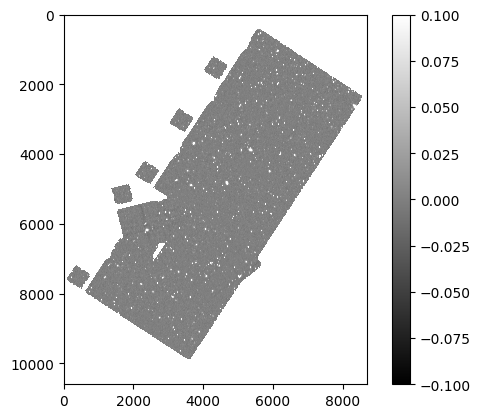

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
from astropy.table import Table
from astropy.wcs import WCS
fitsFile = pyfits.open(r'/home/ben/AGN/Project/jw1207_miri_F770W_mosaic_v0.5_i2d.fits')


#Load the fov image data:
fov_image = fitsFile[1].data # check the back grounp


#Derive the header informaion, might be used to obtain the pixel scale and the exposure time.
header = fitsFile[1].header # if target position is add in WCS, the header should have the wcs information, i.e. header['EXPTIME']


# Access the image data (usually in the first HDU)
image_data = fitsFile[1].data

# Error data 
error_data = fitsFile[2].data

wcs = WCS(header)


# Display the image
plt.imshow(image_data, cmap='gray', vmin=np.min(image_data) * 0.5, vmax=np.max(image_data) * 0.9)
plt.colorbar()
plt.show()


In [ ]:
# Check for extensions 
fitsFile.info()

'''
Extensions info: 

0. Primary
    - Metadata: Contains header information (346 header cards) but no image data.
    - Purpose: Stores general information about the observation, such as:
        - Instrument: MIRI
        - Filter: F770W
        - Exposure time
        - Observation date
        - World Coordinate System (WCS) for spatial mapping

1.  SCI  – Science Image
    - Type: ImageHDU
    - Size: (8700, 10600) pixels
    - Data Format: float32 (floating-point values)
    - Purpose: This is the actual science image containing the observed astronomical data in MJy/sr (MegaJanskys per steradian).
    - Usage: This is the main image used for AGN analysis, photometry, and source extraction.

2. ERR – Uncertainty (Error) Map
    - Type: ImageHDU
    - Size: (8700, 10600) pixels
    - Data Format: float32
    - Purpose: This map represents the 1σ uncertainty for each pixel in the science image.
        - It includes contributions from read noise, photon noise, and background fluctuations.
        - The units match those of the SCI extension (e.g., MJy/sr).
    -  Usage: This is used to weight pixels in fitting procedures and compute flux uncertainties in photometry.
'''

Filename: /home/ben/AGN/Project/jw1207_miri_F770W_mosaic_v0.5_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     346   ()      
  1  SCI           1 ImageHDU        75   (8700, 10600)   float32   
  2  ERR           1 ImageHDU        10   (8700, 10600)   float32   


'\nExtensions info: \n\n0. Primary\n    - Metadata: Contains header information (346 header cards) but no image data.\n    - Purpose: Stores general information about the observation, such as:\n        - Instrument: MIRI\n        - Filter: F770W\n        - Exposure time\n        - Observation date\n        - World Coordinate System (WCS) for spatial mapping\n\n'

In [2]:
from astropy.io import ascii


f = ascii.read(r'/home/ben/AGN/Project/miri_main_agn_lx.dat')
f = f[(f['otype'] == 'AGN' )]
f.rename_column('id_miri', 'miri_id')

In [3]:
p = ascii.read(r'/home/ben/AGN/Project/miri_v0.4.2_coords.dat')
p.rename_column('id_miri', 'miri_id')

In [4]:
from astropy.table import join
cc = 'miri_id'
joined_table = join(f, p, keys=cc)
joined_table

miri_id,redshift,mass_star,lum_agn,tau_agn_ir,tau_agn_opt,agn_sed_final,JL's comment,lum_sfir,sfr_sfir,star search,tag (dw_AGN),tag (hz_AGN),tag (nm_AGN),low SNR tag,star tag,bad source tag,drop tag,tag (SFG),tag (QG),fagn,x_match,lxc,otype,L6_agn,L6_tot,ra,dec
int64,float64,float64,float64,float64,float64,float64,str33,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,str6,float64,float64,float64,float64
2,2.539371596,10.45525328,4.519399367,10.11108713,1.241872285,0.0,--,13.94927182,15392.81052,--,0,0,0,0,0,--,0,1,--,0.0,1,9.2811041,AGN,38.9142,44.2039,53.1255989,-27.8865013
8,2.394942382,10.64987708,4.770992406,4.642340685,1.657090503,0.0,--,7.436032635,0.004721486345,--,0,0,0,0,0,--,0,0,--,1.7e-06,1,9.474127799999998,AGN,39.2176,39.2303,53.1241608,-27.8814983
9,1.017,10.22024961,4.246107284,9.432263041,0.01702127398,0.0,--,11.48697834,53.09143271,--,0,0,0,0,0,--,0,0,--,2e-07,1,8.015265499999998,AGN,38.6872,41.7421,53.1247292,-27.8812695
38,2.020434032,10.57913045,4.256275841,17.28529775,1.421637805,0.0,--,13.0264878,1838.797506,--,0,0,0,0,0,--,0,1,--,0.0,1,8.671813,AGN,38.5606,43.2811,53.1193123,-27.8738003
54,3.881185808,11.35418137,4.302399168,9.699450402,0.009643445042,0.0,redshift might be wrong,14.99237208,169987.9687,--,0,0,0,0,0,--,0,1,--,0.0,1,9.8930121,AGN,38.7405,45.247,53.1466103,-27.8710251
89,3.628873499,10.7892565,8.55868726,0.09158760618,2.97047834,1.0,good example,7.334999848,0.003741501738,--,0,0,1,0,0,--,0,0,--,0.010494,1,9.7621909,AGN,43.0183,43.0183,53.1380234,-27.8682938
123,1.578,10.8778614,4.178368375,1.005832173,2.977190631,0.0,--,13.16048296,2503.393146,--,0,0,0,0,0,--,0,1,--,1e-07,1,10.088156699999999,AGN,38.627,43.4151,53.1364212,-27.8642673
190,3.048857473,10.63312475,9.656622025,13.36155512,1.62310881,1.0,--,7.575586357,0.00651077159,--,0,0,1,0,0,--,0,0,--,0.0008095,1,8.629283000000001,AGN,44.0011,44.0011,53.0854797,-27.8581676
196,2.046048257,10.16781289,4.575511109,10.74282656,1.98943149,0.0,--,13.84722725,12169.51718,--,0,0,0,0,0,--,0,1,--,0.0,1,8.2480002,AGN,38.9396,44.1019,53.0892296,-27.8573513


In [5]:
# Determine the pixel scale from the header, usually under CDELT1/CDELT2
deg_per_pix = abs(header['CDELT1']) # CDELT1 provides the scale in degree per pixel
arcsec_per_pix = deg_per_pix * 3600  # convert degree to arcsec per pixel


# Find the number of pixels in 5 arcsec to cutout
cutout_in_arcsec = 2
cutout_in_pixels = int(cutout_in_arcsec / arcsec_per_pix)


# Coordinates of AGN
RA = joined_table['ra']
DEC = joined_table['dec']
agn_positions = np.column_stack((RA,DEC))  

In [6]:



from astropy.nddata import Cutout2D
# Loop over each AGN position and create cutouts
cutouts = []
for i, (ra, dec) in enumerate(agn_positions):
    # Convert RA/DEC to pixel coordinates
    position = wcs.world_to_pixel_values(ra, dec)
   
    # Create a Cutout2D object
    cutout = Cutout2D(data=image_data, position=position, size=cutout_in_pixels, wcs=wcs)
   
    # Append cutout data to the list
    cutouts.append(cutout)


    # Make it log scale
    log_cutout_data = np.log10(np.clip(cutout.data, a_min=1e-3, a_max=None))


    '''
    np.clip(array, a_min, a_max)
        - Use clip to avoid logging negative or 0
        - np.clip "clip" the array into specified range of values (a_min and a_max). If the values are smaller are larger
        than a_min and a_max, set it back to a_min and a_max
    '''
    
    # Delete comments to plot the cutouts
    '''
    # Plot the cutout
    plt.figure(figsize=(5, 5))
    plt.imshow(log_cutout_data.data, cmap='viridis', vmin=np.min(log_cutout_data) * 0.5, vmax=np.max(log_cutout_data) * 0.9)
    plt.colorbar()
    plt.title(f'AGN Cutout {i+1}')
    plt.show()
    '''

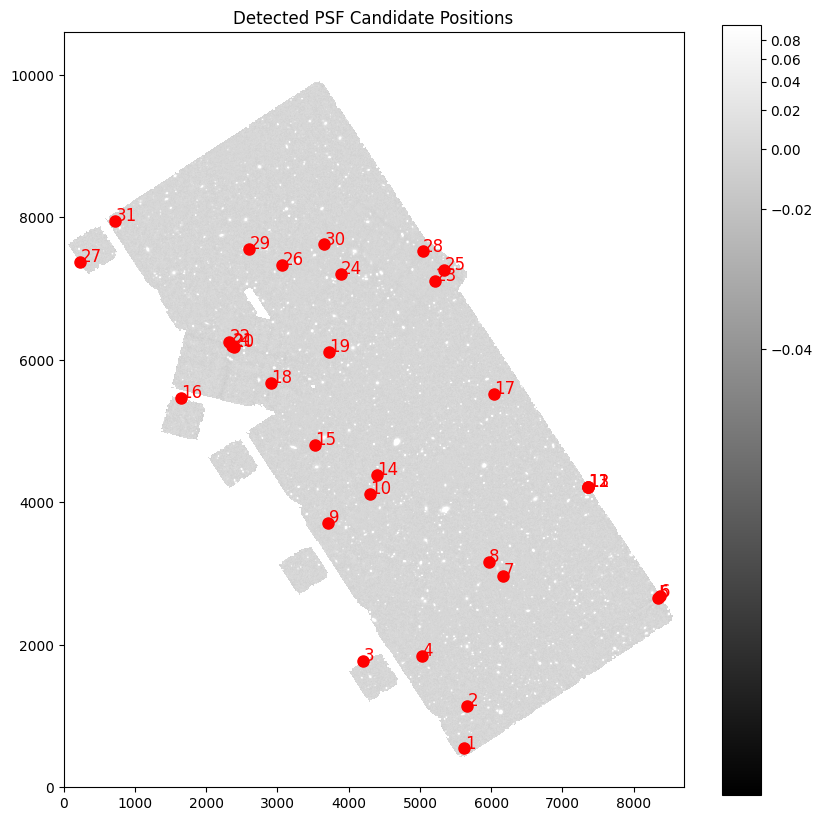

Detected PSF positions: [(5625, 545), (5667, 1143), (4202, 1766), (5025, 1844), (8342, 2656), (8364, 2677), (6167, 2966), (5965, 3160), (3712, 3709), (4297, 4116), (7358, 4218), (7357, 4219), (7358, 4219), (4398, 4381), (3524, 4802), (1642, 5462), (6033, 5523), (2908, 5668), (3722, 6111), (2384, 6184), (2367, 6190), (2321, 6247), (5211, 7099), (3887, 7208), (5338, 7260), (3063, 7323), (233, 7377), (5039, 7519), (2606, 7555), (3653, 7617), (726, 7950)]


In [7]:
from photutils.detection import find_peaks
from astropy.visualization import simple_norm


# Step 1: Define a function to find sources in the image
def detect_sources(data, threshold=500, box_size=30, fwhm_max=5):
    """
    Detect potential PSF candidates in the image.
    Args:
    - data: 2D array, the image data.
    - threshold: Detection threshold (in sigma).
    - box_size: Size of the box for peak finding.
    - fwhm_max: Maximum Full Width Half Maximum (FWHM) for point-like sources.
   
    Returns:
    - List of (x, y) positions of detected PSFs.
    """
    # Find peaks (bright points) in the image
    peaks_tbl = find_peaks(data, threshold, box_size=box_size)
    peaks_tbl['peak_value'].info.format = '%.8g'  # for consistent table output


    # Convert the peak positions (y, x) to (x, y)
    psf_positions = [(row['x_peak'], row['y_peak']) for row in peaks_tbl]
   
    return psf_positions


# Step 2: Visualize the detected sources
def plot_detected_sources(image, psf_positions):
    """
    Plot the original image and mark detected PSF positions.
    Args:
    - image: 2D array, the original image data.
    - psf_positions: List of (x, y) positions of PSFs.
    """
    plt.figure(figsize=(10, 10))
    norm = simple_norm(image, 'log', percent=99)
    plt.imshow(image, origin='lower', cmap='gray', norm=norm)
   
    # Mark the detected positions
    for i, (x, y) in enumerate(psf_positions):
        plt.plot(x, y, 'ro', markersize=8)
        plt.text(x+5, y+5, str(i+1), color='red', fontsize=12)
   
    plt.title("Detected PSF Candidate Positions")
    plt.colorbar()
    plt.show()


# Call the function
psf_positions = detect_sources(fov_image, threshold=5, box_size=30)


# Step 3: Plot the detected PSF candidates
plot_detected_sources(fov_image, psf_positions)


# PSF positions now hold the coordinates [(x1, y1), (x2, y2), ...]
# You can print them out or use them directly for cutouts.
print("Detected PSF positions:", psf_positions)

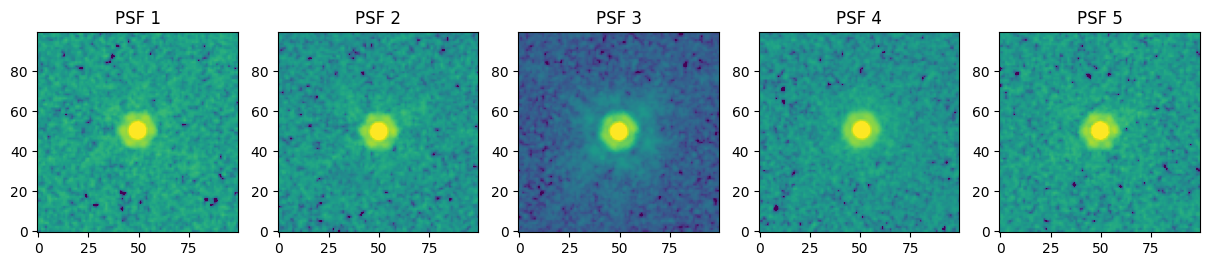

In [8]:
from photutils.segmentation import detect_sources
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from astropy.nddata import Cutout2D
from astropy.visualization import ZScaleInterval, simple_norm
from photutils.background import MMMBackground


# Step 1: Load FITS file and create the exposure map
def create_exp_map(fits_file):
    # Load the Weight (WHT) map from the 3rd extension (index 2)
    wht = fits_file[2].data
    exp = fits_file[1].header['XPOSURE']  # Exposure time from header
    mean_wht = exp * (0.0642 / 0.135)**2  # Derive mean WHT using drizzle info
    exp_map = exp * wht / mean_wht  # Create exposure map
    return exp_map


"""
Weight (WHT) map:
    - Map of 2D array.
    - Use to indicate relative exposure or quality of data per pixel.
    - Higher weight pixel => more accurate.


Drizzle information:
    - A method to combine multiples dithered (many colors) exposures.
    - Drizzling data from different images onto one grid => improving resolution and distortion.
    - Scaling factor (0.0642 / 0.135) : original image vs combined grid.


Exposure map:
    - Exposure time + WHT map => effective exposure of each pixel.
    - Tells how much signal a pixel receive, taking weight/quality of pixels into account.
    - Help to improve measurement of flux in photometric analysis.
"""
# Step 2: Create a source mask
def create_source_mask(data, nsigma=2.8, npixels=15, exp_sz=1.2):
    # Background estimation and subtraction
    sigma_clip = SigmaClip(sigma=nsigma) # clips data values more than nsigma away from local mean, removing outliers
    bkg_estimator = MedianBackground() # taking the median of pixel values in a region
    bkg = Background2D(data, (50, 50), filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
    data_sub = data - bkg.background # subtract background


    # Gaussian smoothing
    # kernel = Gaussian2DKernel(x_stddev=exp_sz)
    # smoothed_data = convolve(data_sub, kernel)
   
    # Detect sources
    threshold = nsigma * bkg.background_rms
    segm = detect_sources(data_sub, threshold, npixels=npixels)
   
    if segm is not None:
        return segm.data > 0  # Create a mask where sources are detected
    else:
        return np.zeros_like(data, dtype=bool)  # Return empty mask if no sources
   
"""
Background2D:
    - Models the background over the entire 2D image.
    - Dividing the images into grids.


threshold:
    - Defines minimum intensity must have to be part of a source.
    - nsigma: set the sigma level/level of importance for source detection.
    - background_rms: root mean square of the background noise.


segm:
    - Segmentation map where detected source has a unique label.
    - Identifies regions of smooth image corresponding to detected sources.
"""


# Step 3: Find and extract PSF cutouts from the image
"""def find_psfs(image, psf_positions, radius=30):
    psfs = []
    for pos in psf_positions:
        cutout = Cutout2D(image, position=pos, size=(2*radius, 2*radius))
        psfs.append(cutout.data)
    return psfs
from photutils.background import MMMBackground""" # No background subtraction


def find_psfs(image, psf_positions, radius=30):
    psfs = []
    bkg_estimator = MMMBackground()  # Use Mean/Median/Mode estimator for background subtraction
   
    for pos in psf_positions:
        cutout = Cutout2D(image, position=pos, size=(2*radius, 2*radius))
        cutout_data = cutout.data
       
        # Estimate and subtract the local background
        bkg = bkg_estimator(cutout_data)
        cutout_data_sub = cutout_data - bkg
       
        psfs.append(cutout_data_sub)
    return psfs # Yes background subtraction


# Step 4: Compare PSF profiles to pick the best one
def compare_psf_profiles(psfs):
    fig, axs = plt.subplots(1, len(psfs), figsize=(15, 5))
    for i, psf in enumerate(psfs):
        norm = simple_norm(psf, 'log', percent=99) # normalize to enhance visibility
        axs[i].imshow(psf, origin='lower', norm=norm, cmap='viridis')
        axs[i].set_title(f'PSF {i+1}')
    plt.show()


# Input the positions of candidate PSFs
psf_pos = [(5667.00, 1143.00),(6033.00, 5523.00), (5211.00, 7099.00),(3887.00, 7208.00), (2606.00, 7555.00)]
# ID = 2, 8, 17, 23, 24, 29
# selected_psf = 0, 1, 2, 3, 4, 5
# ID 8 coord:  (5965.00, 3160.00)
# Load FITS file and image data
exp_map = create_exp_map(fitsFile)  # Create exposure map


# Step 5: Generate PSF cutouts and compare
psfs = find_psfs(fov_image, psf_pos, radius=50)
compare_psf_profiles(psfs)


# Let the user select which PSF to use for fitting
psf_id = int(input('Select PSF ID for fitting (0, 1, 2, ...): '))
selected_psf = psfs[psf_id] # User's choice of PSF will be saved here


# Use `selected_psf` for PSF fitting in modeling process

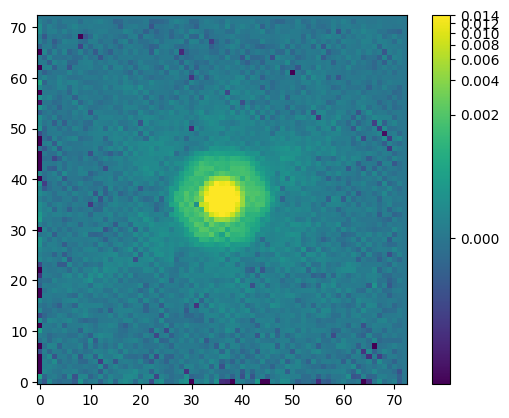

In [9]:
from astropy.table import Table
from photutils.psf import EPSFBuilder, extract_stars
from astropy.nddata import NDData
from astropy.coordinates import SkyCoord
from astropy.convolution import Gaussian2DKernel


# Convert positions in psf_pos into a Table object
# Convert to table so extract_stars can work easier later on
catalog = Table(names=['x', 'y'], data=[np.array([x for x, y in psf_pos]), np.array([y for x, y in psf_pos])])


# Step 1: Extract PSF stars using extract_stars (needs catalog and image)
# catalog typically contains coordinates (x, y) for each detected star or source and additional data
stars = extract_stars(NDData(fov_image), catalog, size=(71, 71)) # extract stars without smoothing


"""
# Gaussian smoothing
smoothed_data = convolve(fov_image, Gaussian2DKernel(x_stddev=1.0))
# Extract stars after applying smoothing
stars = extract_stars(NDData(smoothed_data), catalog, size=(51, 51))
"""
"""
Gaussian Smoothing: convolving the image with a Gaussian kernel (higher weights to central pixels and
smaller weights to neighoring pixels). It smooths the data by averaging these surrounding pixels based
on the Gaussian distribution to reducing noise and maintain point source structures.
"""
# Step 2: Initialize and build the ePSF
# Since the EPSFBuilder use the PSF directly from the Table earlier, no need to convert from NDData
kernel = None
epsf_builder = EPSFBuilder(oversampling=1, maxiters=15, smoothing_kernel= kernel , progress_bar=True)
epsf, fitted_stars = epsf_builder(stars)


"""
EPSFBuilder Parameters:
    - oversampling: control epsf grid to pixel scale. Higher value -> more resolution but also more noise.
    - maxiters: # of iterations for refining psf. More iterations -> smoother and also more noise.
    - smoothing_kernal: Kernel is used to smooth the data or suppress noise. Apply Gaussian smoothing
    each iteration if use Gaussian2DKernel. Removing kernal (set the parameter to None) can also
    help to get a better data since it removes the smoothing which can make the data more accurate.
"""


# Step 3: Plot the ePSF
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
norm = simple_norm(epsf.data, 'log', percent=99.0)
plt.imshow(epsf.data, norm=norm, origin='lower', cmap='viridis')
plt.colorbar()
plt.show()


In [ ]:
from astropy.io import fits

# Open the FITS file
with fitsFile as hdul:
    noise_map = hdul['ERR'].data  # Extract the noise map from the ERR extension

Set DATE-AVG to '2022-12-16T08:51:18.051' from MJD-AVG.
Set DATE-END to '2023-01-28T18:36:13.203' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    13.292646 from OBSGEO-[XYZ].
Set OBSGEO-H to 1649518427.990 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


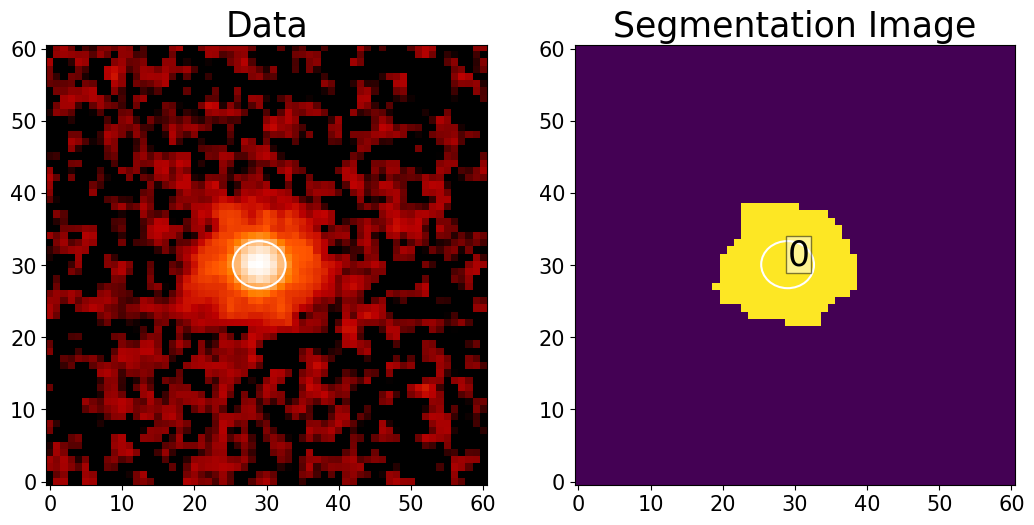

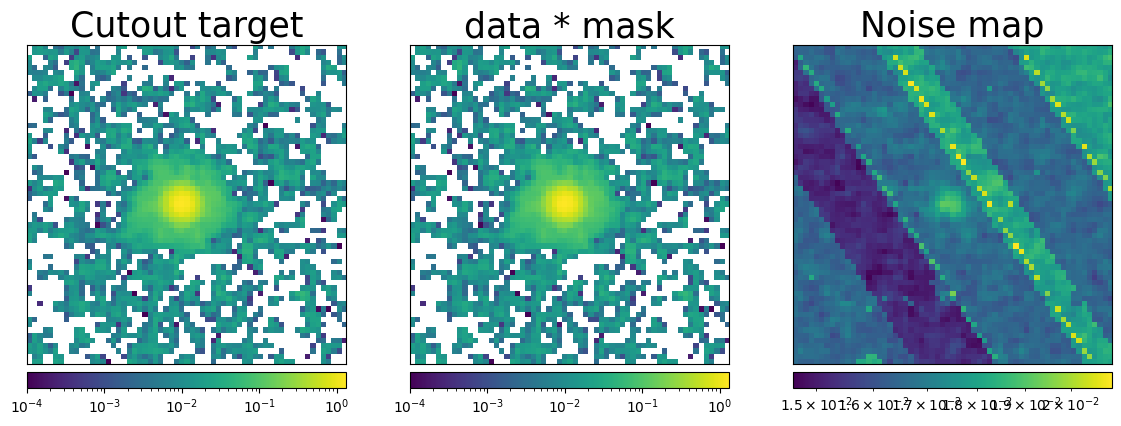

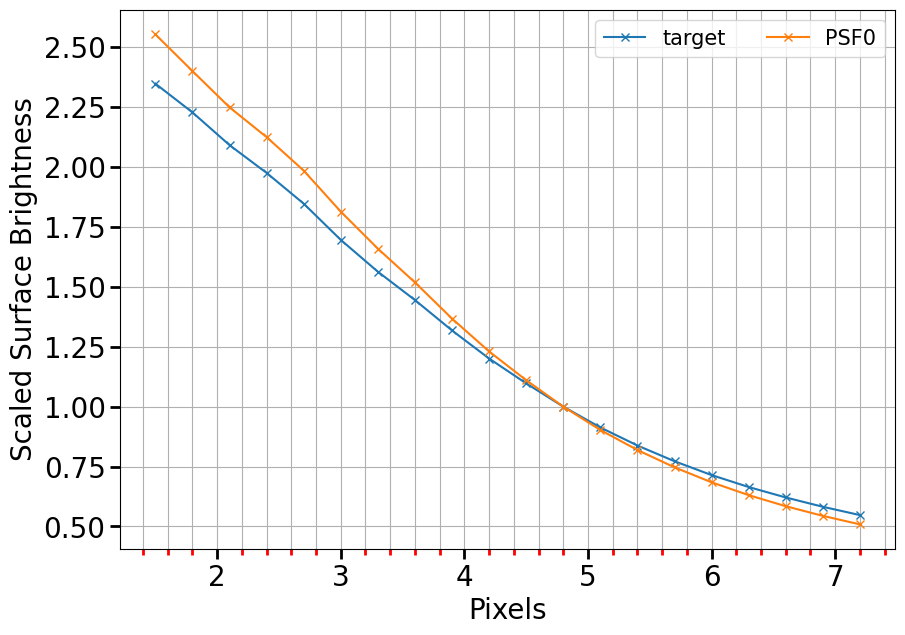

The negative PSF values are corrected as 0 values.
The data_process is ready to go to pass to FittingSpecify!


In [11]:

# Import modules for fitting
from galight.data_process import DataProcess
from galight.fitting_specify import FittingSpecify

# Initialize source data
data = cutouts[16].data 

# Define the center position for the AGN source within the cutout
target_pos = [[cutouts[16].shape[1] // 2, cutouts[16].shape[0] // 2]]  # Center position in the cutout
data_process = DataProcess(fov_image = fov_image, fov_noise_map = noise_map , target_pos = [RA[15], DEC[15]],
                           pos_type = 'wcs', header = header,
                          rm_bkglight = False, if_plot=False, zp = 27)


# Generate the fitting material
data_process.generate_target_materials(radius = 30, create_mask = True, nsigma = 2.8, exp_sz = 1.2, npixels = 15, if_plot = True)

# Manually input the PSF:
data_process.PSF_list = [epsf.data]

# Compare the 1D profile of all the components.
data_process.profiles_compare(norm_pix = 5, if_annuli = False, y_log = False,
                  prf_name_list = (['target'] + ['PSF{0}'.format(i) for i in range(len(data_process.PSF_list))]) )


# Check if all the materials is given, if so to pass to the next step.
data_process.checkout() #Check if all the materials is known.

/home/ben/.local/lib/python3.10/site-packages/galight/fitting_specify.py:183: UserWarning: 
  warnings.warn("\nWarning: could not find the enough number of local max to match the PS numbers. Thus, all the initial PS set the same initial parameters.")


The settings for the fitting is done. Ready to pass to FittingProcess. 
  However, please make updates manullay if needed.


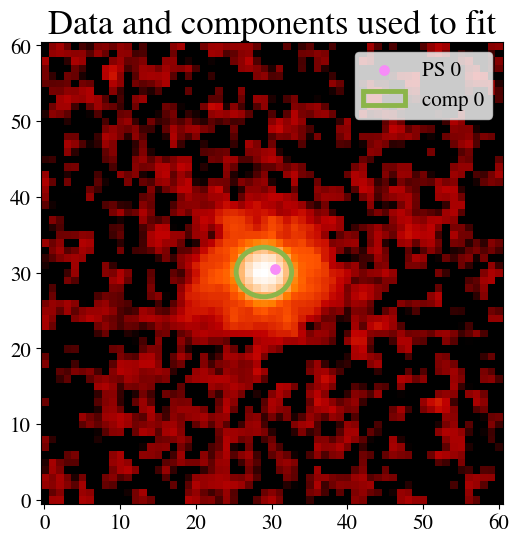

In [12]:
# Start to produce the class and params for lens fitting.
from galight.fitting_specify import FittingSpecify

fit_sepc = FittingSpecify(data_process)
fit_sepc.prepare_fitting_seq(point_source_num = 1)

# Using following line: want to fix Sersic_n as 4 for the source_id = 0, and if want to fix the QSO and host center:
# fit_sepc.prepare_fitting_seq(point_source_num = 1, fix_n_list= [[0,4]], fix_center_list = [[0,0]])

# Plot the initial settings for fittings. fits.open("your_jwst_data.fits")
fit_sepc.plot_fitting_sets()

fit_sepc.build_fitting_seq()

Computing the PSO ...
10
20
30
40
50
Max iteration reached! Stopping.
-0.7090953866831978 reduced X^2 of best position
-1315.7264899906736 log likelihood
3711.0 effective number of data points
[] lens result
[] source result
[{'amp': 1, 'R_sersic': 0.21665204110222297, 'n_sersic': 3.839824712792949, 'e1': 0.08431511492849444, 'e2': 0.14511710123614446, 'center_x': 0.10424116280930551, 'center_y': 0.014322065526751538}] lens light result
[{'ra_image': array([0.03596215]), 'dec_image': array([0.00789078]), 'point_amp': array([1.])}] point source result
[] tracer source result
{} special param result
12.261314630508423 time used for  PSO
MCMC selected. Sampling with default option emcee.
re-using previous samples to initialize the next MCMC run.


100%|██████████| 130/130 [00:35<00:00,  3.68it/s]


Computing the MCMC...
Number of walkers =  80
Burn-in iterations:  100
Sampling iterations (in current run): 130
35.73982858657837 time taken for MCMC sampling
48.342 total time taken for the overall fitting (s)
============ CONGRATULATION, YOUR JOB WAS SUCCESSFUL ================ 
Start transfering the Params to fluxs...
2400 MCMC samplers in total, finished translate: 1000
2400 MCMC samplers in total, finished translate: 2000


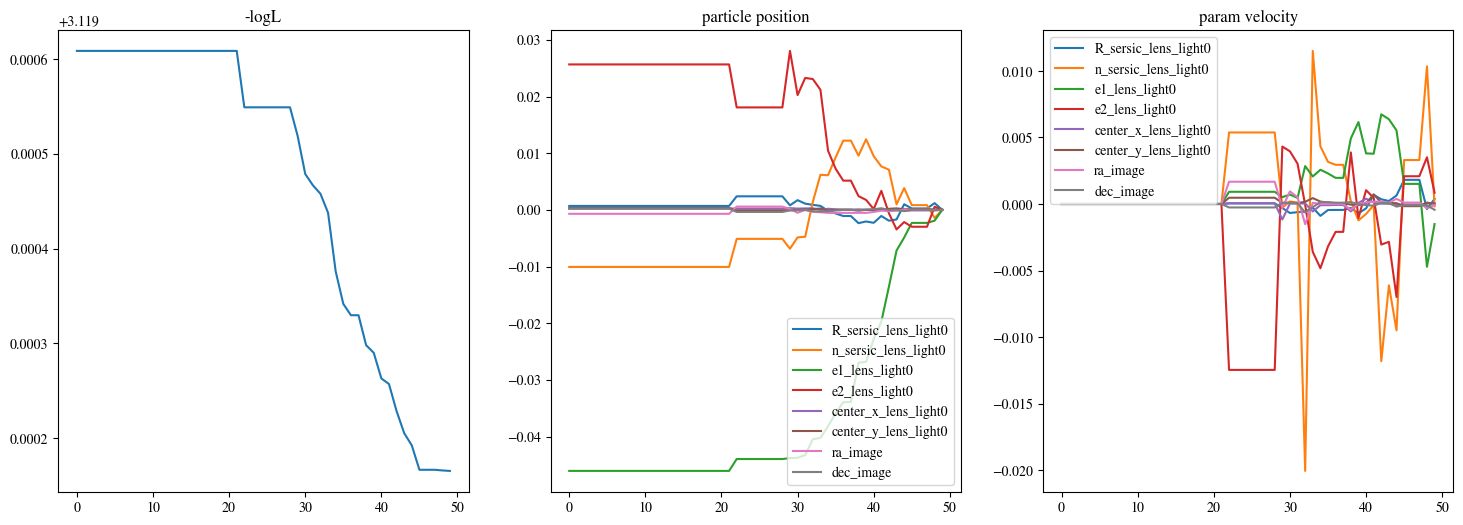

<Figure size 640x480 with 0 Axes>

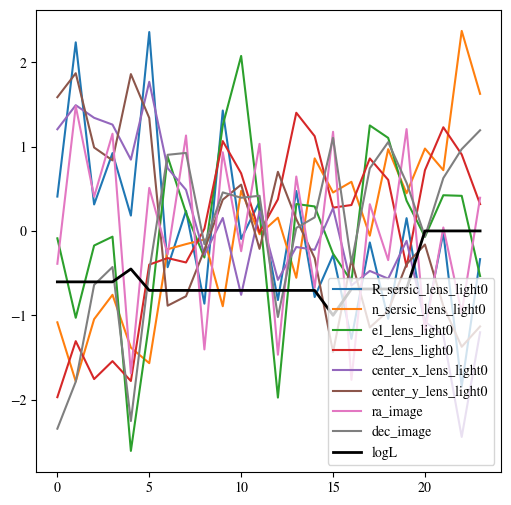

-0.7076911449384908 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.7076911449384908


/home/ben/.local/lib/python3.10/site-packages/lenstronomy/Plots/model_band_plot.py:160: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/home/ben/.local/lib/python3.10/site-packages/lenstronomy/Plots/model_band_plot.py:1157: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data - model),


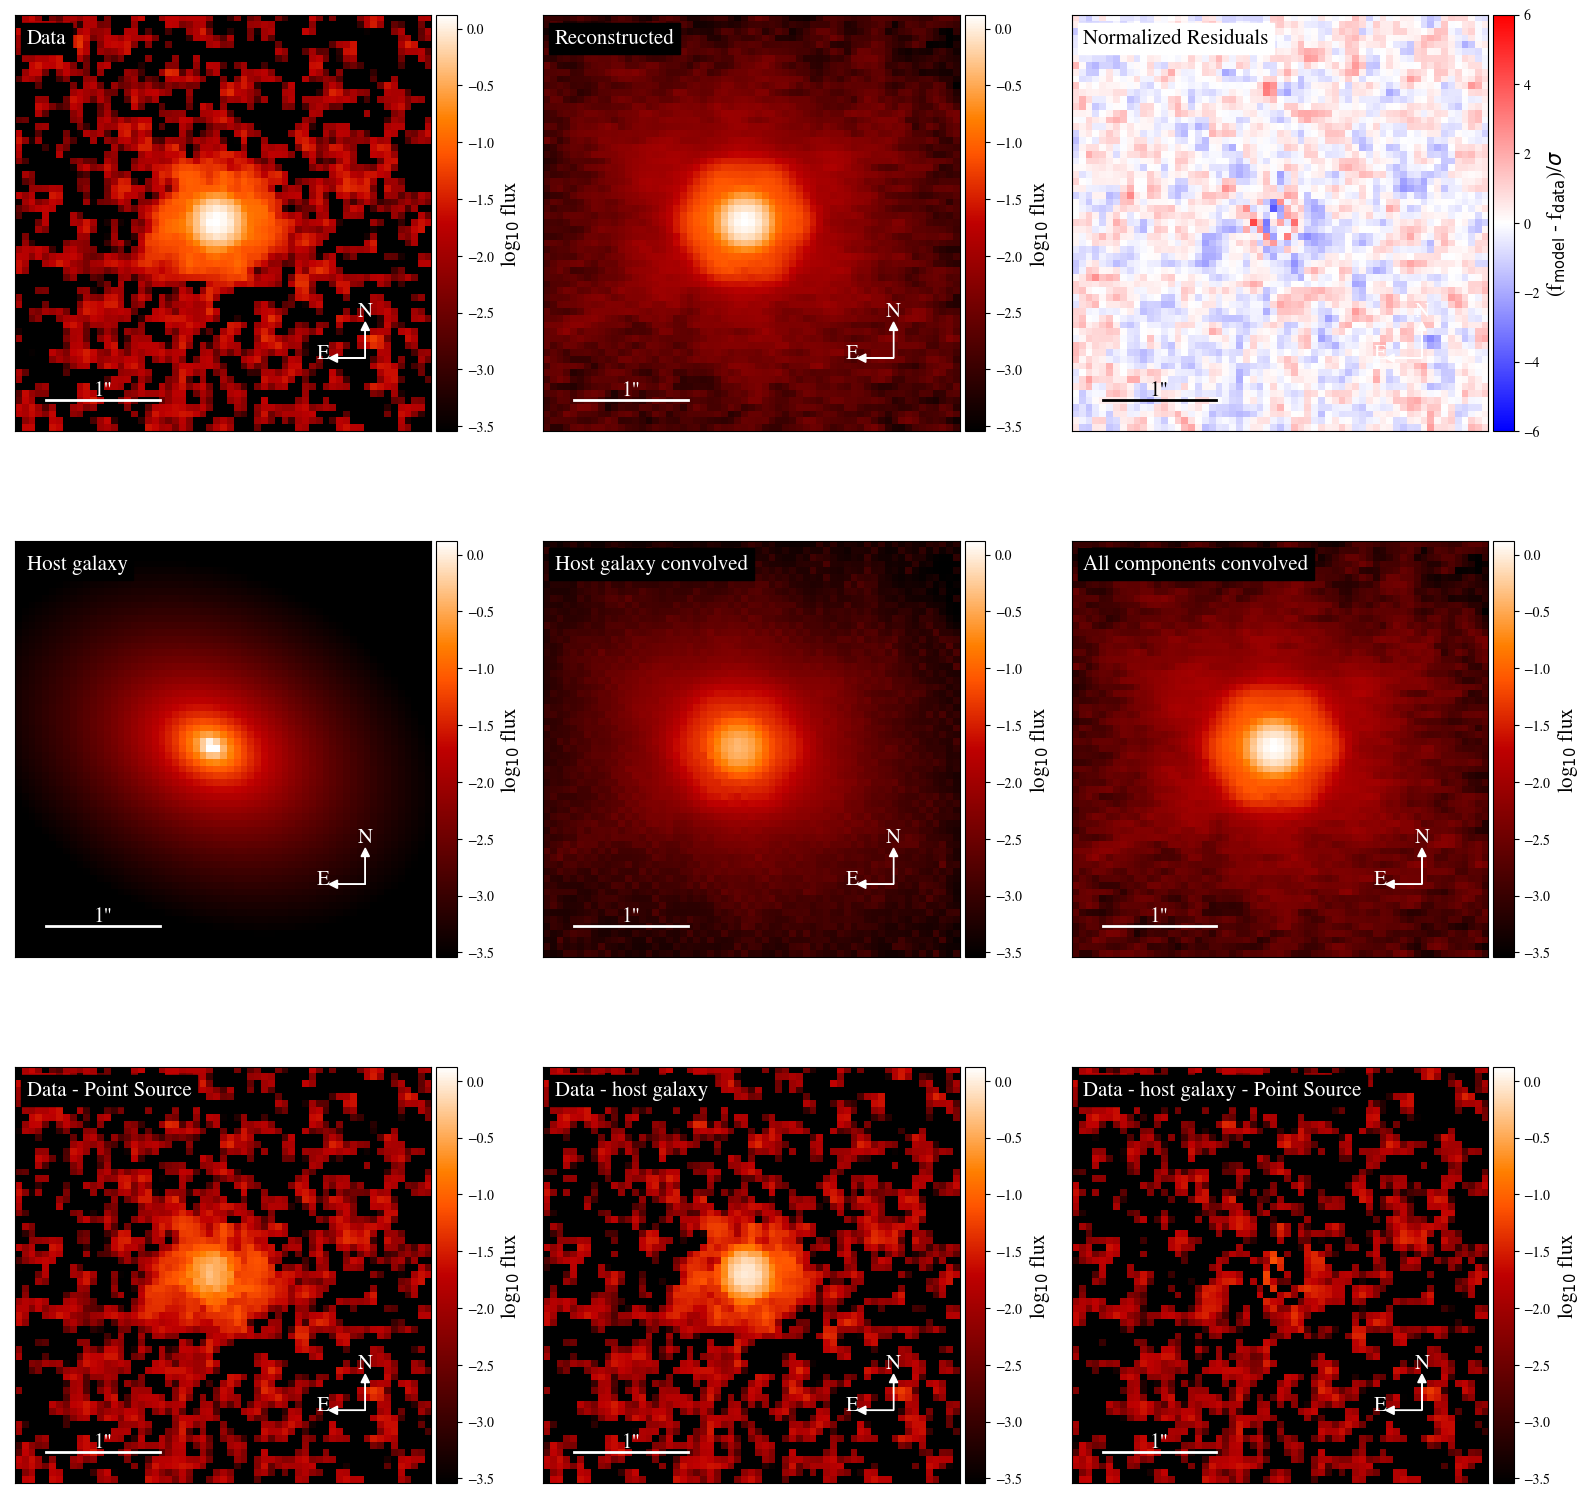

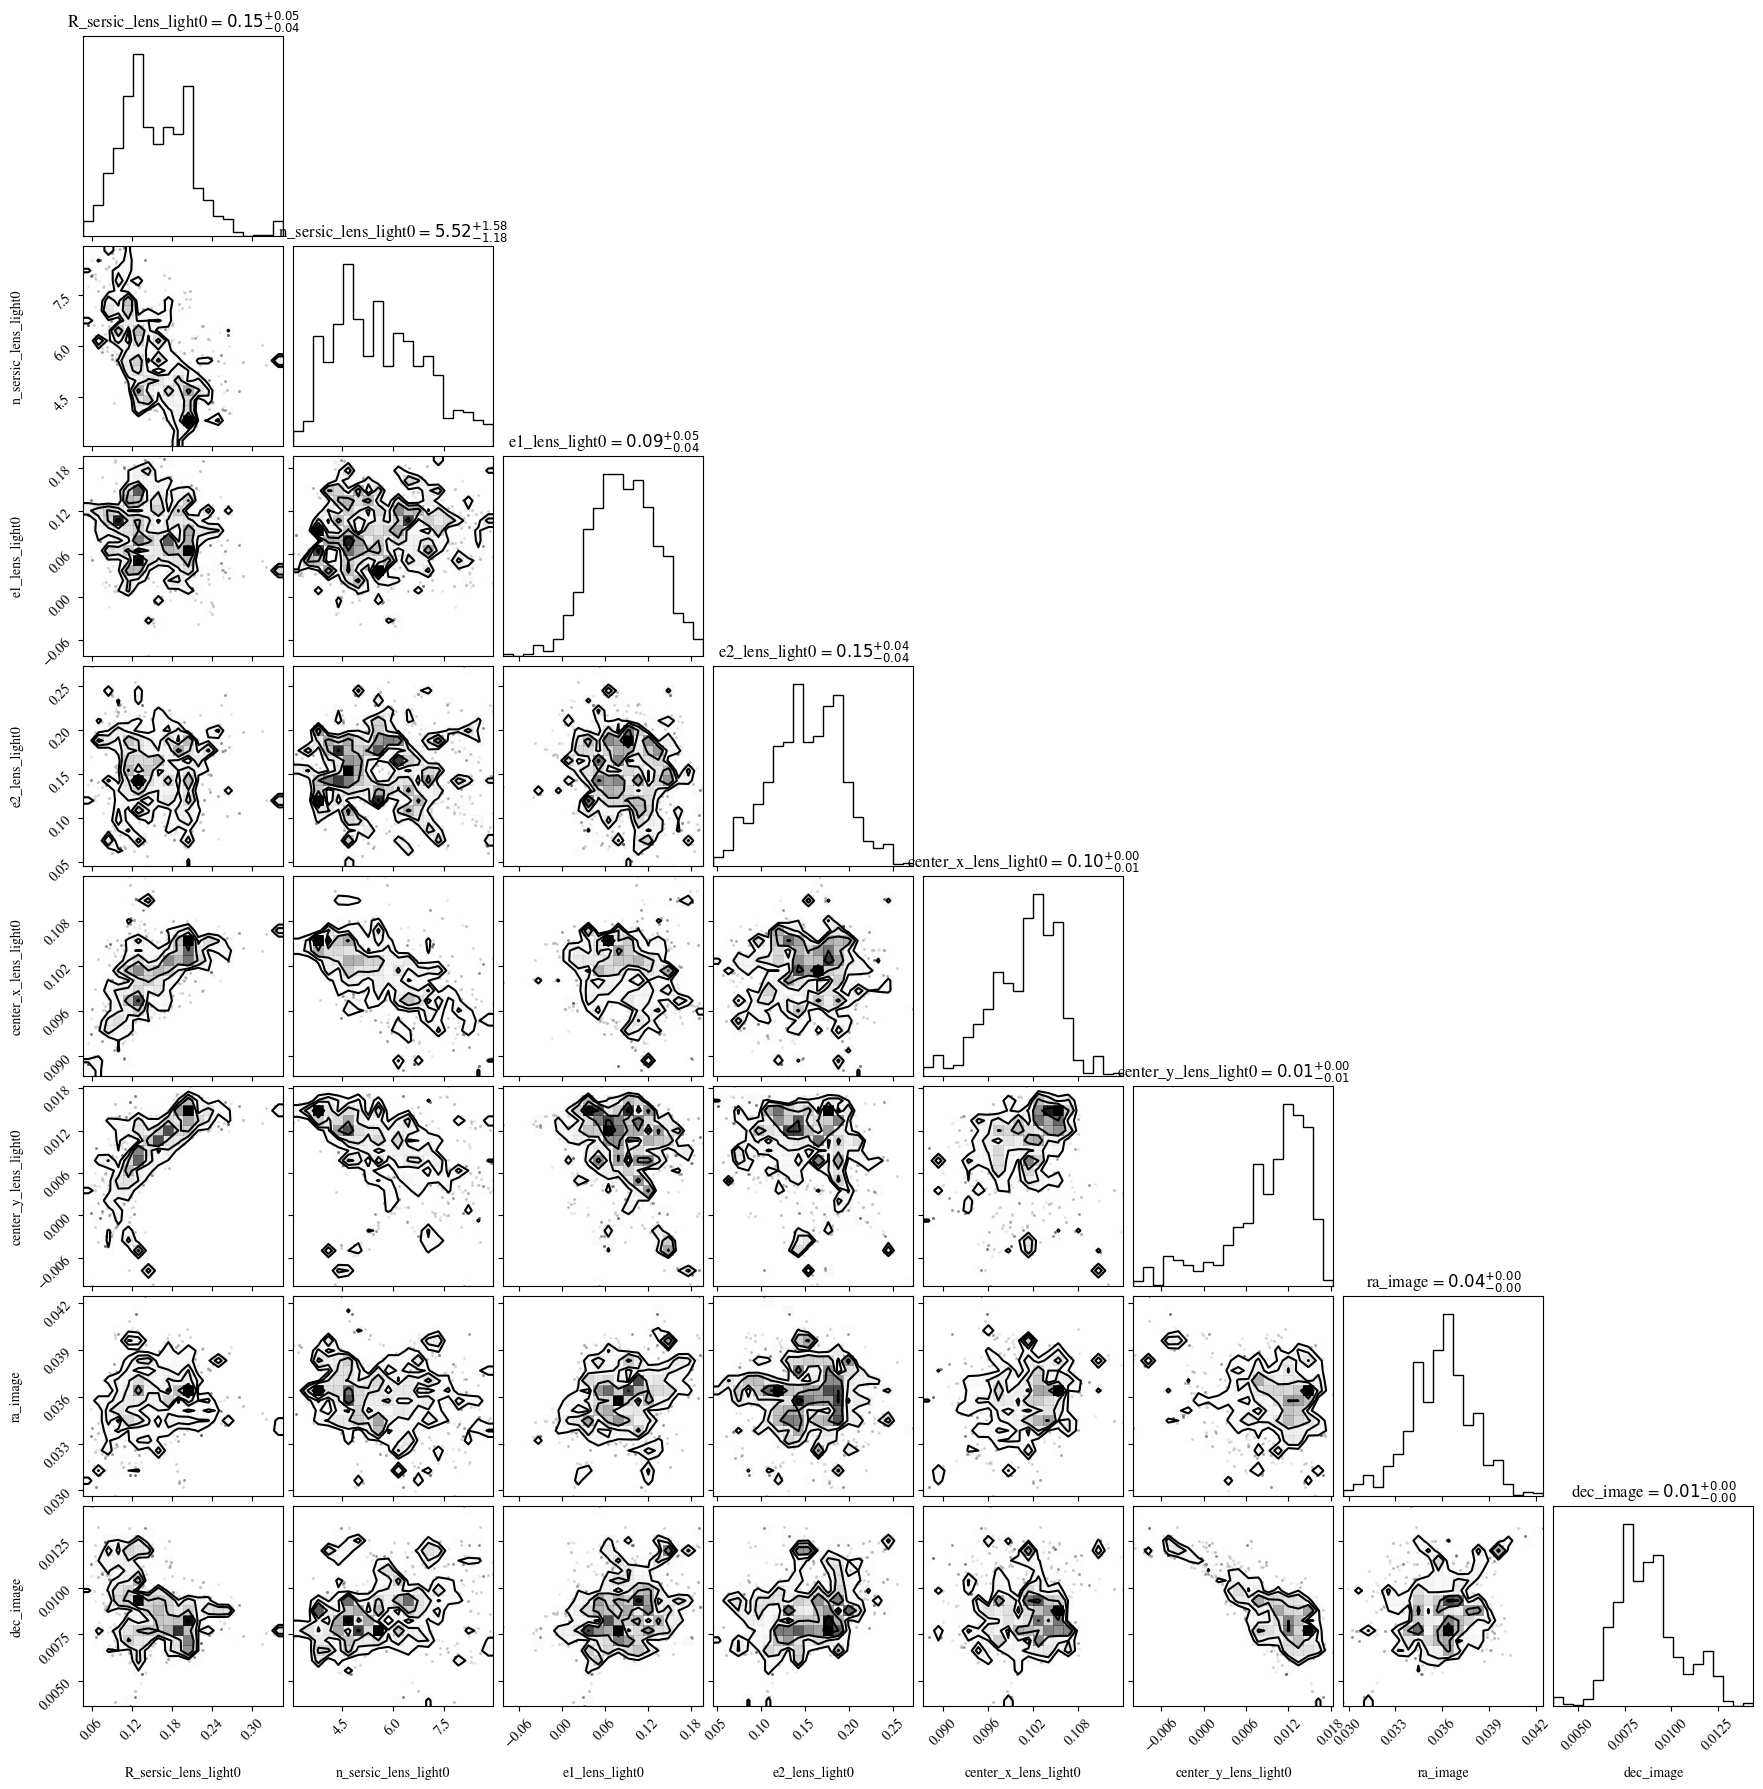

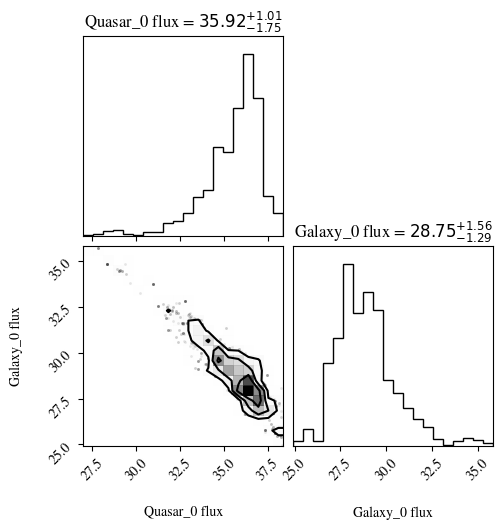

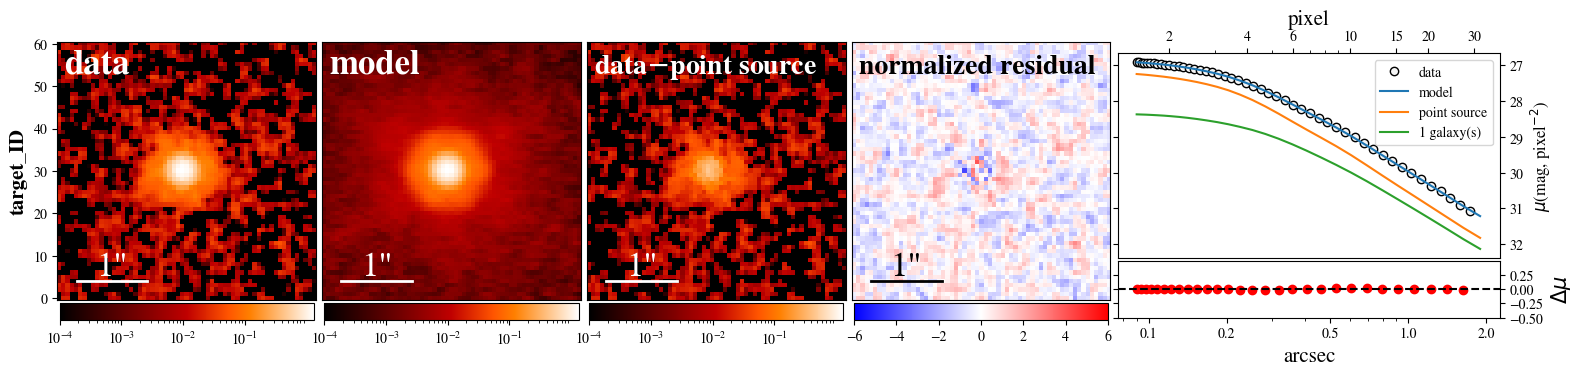

In [18]:
# For the fitting_level, you can also put ['shallow', 'deep'] for the later ['PSO', 'MCMC'] corresplingly.

# Setting the fitting approach and Run: 
#     algorithm_list: The fitting approaches that would be used: e.g. ['PSO', 'PSO', 'MCMC']
#     setting_list: The detailed setting for the fitting can be as follows.
#     -for PSO:
#         input template: {'sigma_scale': 0.8, 'n_particles': 50, 'n_iterations': 50}
#     -for MCMC:
#         input template: {'n_burn': 50, 'n_run': 100, 'walkerRatio': 10, 'sigma_scale': .1}
#     if setting_list = [None, None, None], default values would be given 
fit_run.run(algorithm_list = ['PSO', 'MCMC'], setting_list = [None, None]) 

#Try also setting_list = [{'sigma_scale': 0.8, 'n_particles': 50, 'n_iterations': 50}, {'n_burn': 50, 'n_run': 100, 'walkerRatio': 10, 'sigma_scale': .1}]

# Plot all the fitting results, including:
#         run_diag() : The convergence of the chains.
#         model_plot(): The model plot (by lenstronomy)
#         plot_params_corner(): The mcmc corner for all the chains (MCMC should be peformed) 
#         plot_flux_corner(): The flux corner for all the component (MCMC should be peformed)
#         plot_final_qso_fit() or plot_final_galaxy_fit(): Plot the overall plot (data, model, data-ps, resudal, 1D profile)
fit_run.plot_all()


#Save the fitting class as pickle format:
fit_run.dump_result(savedata = False)  # can set savedata= True to save the data_process_class